In [1]:
import zipfile
import os

zip_path = "plant_village_dataset.zip"  # your uploaded file
extract_to = "plantvillage"  # folder to extract to

# Unzip the dataset
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("✅ Unzipped Successfully!")


✅ Unzipped Successfully!


In [ ]:
# List folders inside extracted dataset
import os

base_dir = "plantvillage"

# Walk through and list the first few folder names
for root, dirs, files in os.walk(base_dir):
    print(f"📂 Directory: {root}")
    print(f"📁 Subfolders: {dirs}")
    print(f"📄 Files: {files[:5]}")  # only show first 5 files
    break  


📂 Directory: plantvillage
📁 Subfolders: ['PlantVillage']
📄 Files: []


In [3]:
import os

# Correct path to your dataset
dataset_path = "plantvillage/PlantVillage"

# List folders and files
for root, dirs, files in os.walk(dataset_path):
    print(f"📂 Directory: {root}")
    print(f"📁 Subfolders: {dirs}")
    print(f"📄 Files: {files[:5]}")  # show only first 5 files
    break


📂 Directory: plantvillage/PlantVillage
📁 Subfolders: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_healthy', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_mosaic_virus', 'Tomato__Tomato_YellowLeaf__Curl_Virus']
📄 Files: []


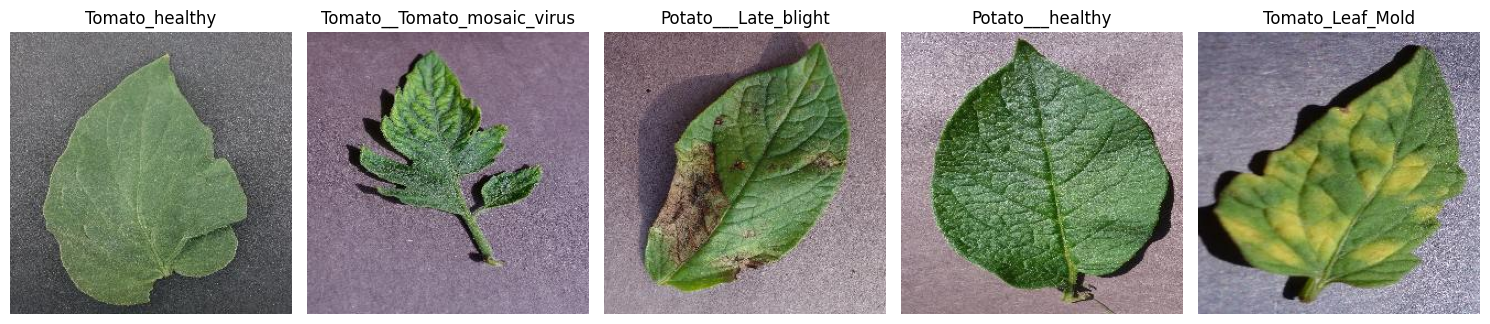

In [4]:
import matplotlib.pyplot as plt
import random
from PIL import Image

def show_random_images(base_path, n=5):
    categories = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]
    plt.figure(figsize=(15, 5))

    for i in range(n):
        class_name = random.choice(categories)
        class_path = os.path.join(base_path, class_name)
        image_name = random.choice(os.listdir(class_path))
        image_path = os.path.join(class_path, image_name)

        img = Image.open(image_path)

        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Call the function with the correct path
show_random_images("plantvillage/PlantVillage", n=5)


In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Constants
IMAGE_SIZE = (128, 128)
BATCH_SIZE = 32
DATA_DIR = "plantvillage/PlantVillage"

# Image Data Generator for preprocessing and augmentation
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # 20% validation
)

# Training Data
train_data = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Validation Data
val_data = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)


Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.


In [3]:
from tensorflow.keras import Input

model = Sequential([
    Input(shape=(128, 128, 3)),  # 👈 Recommended way to define input
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(train_data.num_classes, activation='softmax')
])


In [5]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [6]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)


C:\Users\dhumm\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 425s 811ms/step - accuracy: 0.4327 - loss: 1.7717 - val_accuracy: 0.7875 - val_loss: 0.6353
Epoch 2/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 129s 249ms/step - accuracy: 0.7536 - loss: 0.7389 - val_accuracy: 0.8336 - val_loss: 0.4929
Epoch 3/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 104s 201ms/step - accuracy: 0.8206 - loss: 0.5235 - val_accuracy: 0.8729 - val_loss: 0.3920
Epoch 4/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 102s 198ms/step - accuracy: 0.8564 - loss: 0.4242 - val_accuracy: 0.8593 - val_loss: 0.4227
Epoch 5/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 124s 240ms/step - accuracy: 0.8873 - loss: 0.3345 - val_accuracy: 0.8976 - val_loss: 0.3143
Epoch 6/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 270s 522ms/step - accuracy: 0.9010 - loss: 0.2794 - val_accuracy: 0.9175 - val_loss: 0.2613
Epoch 7/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 313s 606ms/step - accuracy: 0.9280 - loss: 0.2110 - val_accuracy: 0.9231 - val_loss: 0.2572
Epoch 8/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 104s 202ms/step - accuracy: 0.9425 -

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 507ms/step


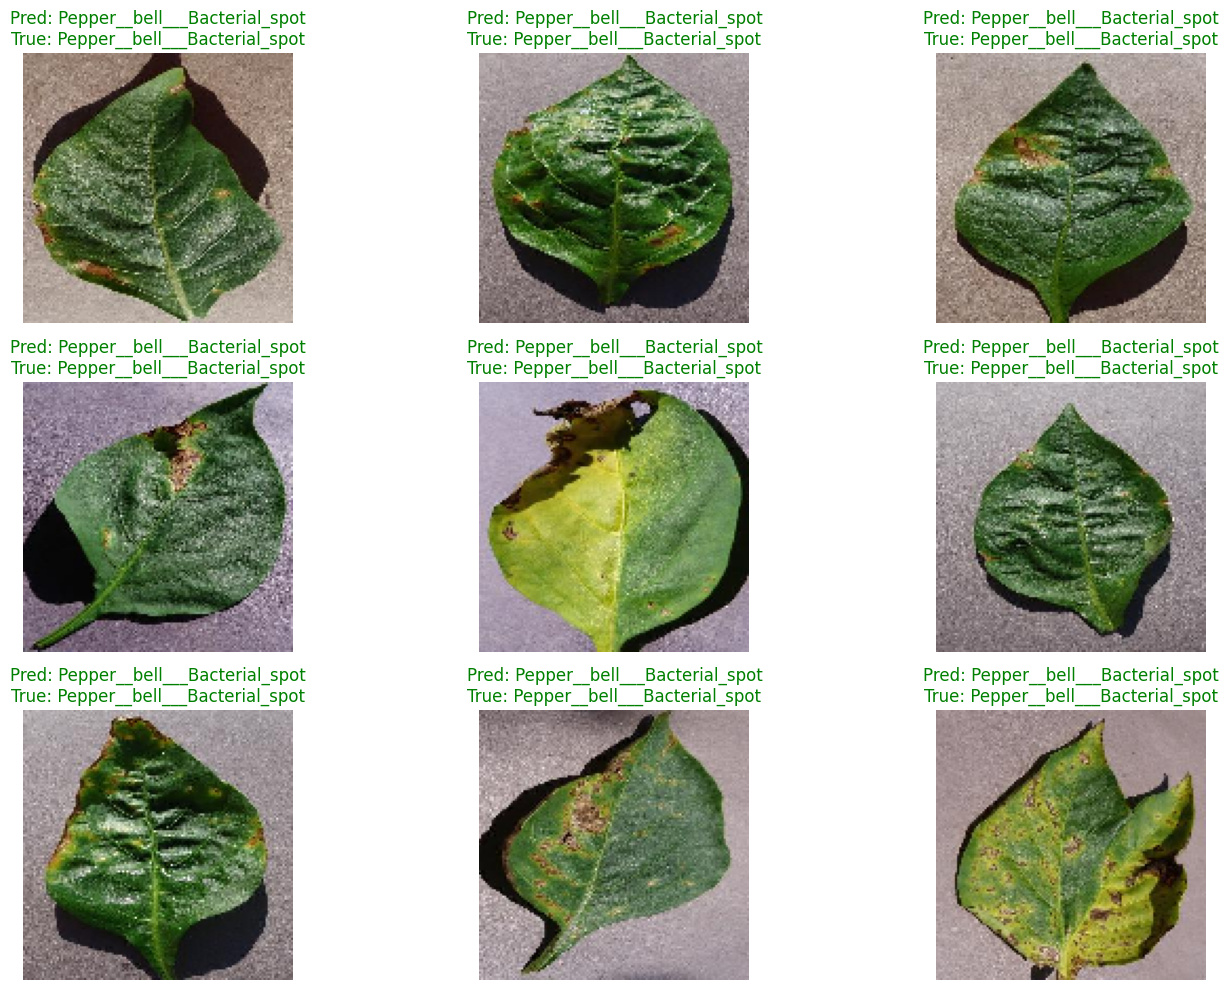

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import random
import os

# Load class names
class_names = list(val_data.class_indices.keys())

# Pick random batch from validation dataset
val_images, val_labels = next(iter(val_data))

# Predict using the trained model
predictions = model.predict(val_images)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(val_labels, axis=1)

# Show a few sample images with predicted and true labels
plt.figure(figsize=(15, 10))
for i in range(9):
    idx = random.randint(0, len(val_images) - 1)
    plt.subplot(3, 3, i + 1)
    plt.imshow(val_images[idx])
    plt.title(f"Pred: {class_names[predicted_classes[idx]]}\nTrue: {class_names[true_classes[idx]]}",
              color='green' if predicted_classes[idx] == true_classes[idx] else 'red')
    plt.axis('off')

plt.tight_layout()
plt.show()


In [9]:
model.save("plant_disease_model.keras")



In [11]:
from keras.models import load_model
from keras.optimizers import RMSprop

model = load_model("plant_disease_model.keras", compile=False)  # Avoid loading incompatible optimizer
model.compile(optimizer=RMSprop(), loss='categorical_crossentropy', metrics=['accuracy'])


In [12]:
import tensorflow as tf

# Load the trained model
model = tf.keras.models.load_model("plant_disease_model.keras")

# Convert to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the converted model
with open("plant_disease_model.tflite", "wb") as f:
    f.write(tflite_model)

print("Model converted to TFLite and saved.")


INFO:tensorflow:Assets written to: C:\Users\dhumm\AppData\Local\Temp\tmpdxx5y7gl\assets


INFO:tensorflow:Assets written to: C:\Users\dhumm\AppData\Local\Temp\tmpdxx5y7gl\assets


Saved artifact at 'C:\Users\dhumm\AppData\Local\Temp\tmpdxx5y7gl'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 15), dtype=tf.float32, name=None)
Captures:
  2887033949840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2887073259664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2887073260816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2887073261392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2887073260624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2887073262160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2887073261584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2887073262928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2887073260240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2887073264272: TensorSpec(shape=(), dtype=tf.resource, name=None)
Model